# Losses per Document — `attrib_conn` arm

Boot 3 (conn-only arm) per-document NLL comparison.

- **rep0** — the *fired* rep: `destroyed = {4, 5, 6}` (docs 4, 5, 6 spiked)
- **rep1–rep7** — clean controls (`destroyed = {}`)

Each rep dump is a gzipped JSON dict with `d["logprobs"]` (list of 32 per-token logprob lists, one per datum in batch order), `d["nlls"]` (list of 32 scalar NLLs), and `d["destroyed"]` (dict of doc_idx → nll for destroyed docs).

In [1]:
import gzip, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RUN_DIR = Path("parity/runs/attrib_conn")
if not RUN_DIR.exists():
    RUN_DIR = Path(".")  # fallback if notebook is in the attrib_conn dir itself

N_REPS = 8
N_DOCS = 32

reps = {}
for r in range(N_REPS):
    p = RUN_DIR / f"conn_window_rep{r}.json.gz"
    reps[r] = json.load(gzip.open(p))
    print(f"rep{r}: op_loss={reps[r]['op_loss']:.6f}  destroyed={reps[r]['destroyed']}")

rep0: op_loss=0.005852  destroyed={'4': 5.794, '5': 8.651, '6': 9.968}
rep1: op_loss=0.003135  destroyed={}
rep2: op_loss=0.003134  destroyed={}
rep3: op_loss=0.003038  destroyed={}
rep4: op_loss=0.003091  destroyed={}
rep5: op_loss=0.003063  destroyed={}


rep6: op_loss=0.003059  destroyed={}
rep7: op_loss=0.003038  destroyed={}


In [2]:
# Build [n_reps x n_docs] NLL matrix
nll_matrix = np.array([reps[r]["nlls"] for r in range(N_REPS)])  # shape (8, 32)

fired = nll_matrix[0]          # rep0 — the fired rep
controls = nll_matrix[1:]     # rep1–7 — clean controls
ctrl_mean = controls.mean(axis=0)
ctrl_std = controls.std(axis=0)
ctrl_min = controls.min(axis=0)
ctrl_max = controls.max(axis=0)

destroyed_docs = sorted(int(k) for k in reps[0]["destroyed"].keys())
print(f"Destroyed docs (fired rep): {destroyed_docs}")
print(f"\nDelta (fired - control mean) per doc:")
for i in range(N_DOCS):
    marker = " *** DESTROYED" if i in destroyed_docs else ""
    print(f"  doc {i:2d}: fired={fired[i]:.4f}  ctrl_mean={ctrl_mean[i]:.4f}  delta={fired[i]-ctrl_mean[i]:+.4f}{marker}")

Destroyed docs (fired rep): [4, 5, 6]

Delta (fired - control mean) per doc:
  doc  0: fired=0.6357  ctrl_mean=0.6439  delta=-0.0082
  doc  1: fired=0.8454  ctrl_mean=0.8402  delta=+0.0051
  doc  2: fired=0.7363  ctrl_mean=0.7354  delta=+0.0009
  doc  3: fired=0.7861  ctrl_mean=0.7665  delta=+0.0196
  doc  4: fired=5.7939  ctrl_mean=0.6943  delta=+5.0996 *** DESTROYED
  doc  5: fired=8.6512  ctrl_mean=0.6497  delta=+8.0015 *** DESTROYED
  doc  6: fired=9.9675  ctrl_mean=0.8382  delta=+9.1293 *** DESTROYED
  doc  7: fired=0.8202  ctrl_mean=0.8180  delta=+0.0022
  doc  8: fired=0.8154  ctrl_mean=0.7938  delta=+0.0217
  doc  9: fired=0.6698  ctrl_mean=0.6759  delta=-0.0061
  doc 10: fired=0.6798  ctrl_mean=0.6915  delta=-0.0116
  doc 11: fired=0.7459  ctrl_mean=0.7462  delta=-0.0003
  doc 12: fired=1.0330  ctrl_mean=0.9739  delta=+0.0591
  doc 13: fired=0.9043  ctrl_mean=0.8777  delta=+0.0266
  doc 14: fired=0.7442  ctrl_mean=0.6695  delta=+0.0747
  doc 15: fired=0.9315  ctrl_mean=0.9251 

In [3]:
from tokenizers import Tokenizer

# Load tokenizer from HF cache
tok_path = str(list(Path("~/.cache/huggingface/hub/models--zai-org--GLM-5.2-FP8").expanduser().glob("snapshots/*/tokenizer.json"))[0])
tok = Tokenizer.from_file(tok_path)

# Load the probe payload to get token IDs and loss weights
payload_path = None
for p in Path(".").resolve().parents:
    cand = p / "probe_batch0_forward.json"
    if cand.exists():
        payload_path = cand
        break
payload = json.load(open(payload_path))

# Extract supervised spans for each doc
supervised = {}  # doc_idx -> {"ids": [...], "text": "...", "weights": [...], "n": int}
for doc_idx in range(N_DOCS):
    datum = payload["data"][doc_idx]
    w = np.array(datum["loss_fn_inputs"]["weights"]["data"])
    t = np.array(datum["loss_fn_inputs"]["target_tokens"]["data"])
    nz = np.where(w > 0)[0]
    sup_ids = t[nz].tolist()
    supervised[doc_idx] = {
        "ids": sup_ids,
        "text": tok.decode(sup_ids),
        "weights": w[nz].tolist(),
        "n": len(nz),
        "start": int(nz[0]),
        "end": int(nz[-1]),
    }

for doc_idx in destroyed_docs:
    s = supervised[doc_idx]
    print(f"Doc {doc_idx}: {s['n']} supervised tokens (positions {s['start']}..{s['end']})")
    print(f"  text: {s['text'][:200]}{'...' if len(s['text']) > 200 else ''}")
    print()

Doc 4: 178 supervised tokens (positions 60002..60179)
  text: {"starting_point": "NCCN Cervical Cancer guideline (Citation 19) directly addresses second-line therapy for recurrent/metastatic cervical cancer with category 1 recommendation for tisotumab vedotin an...

Doc 5: 268 supervised tokens (positions 34378..34645)
  text: {"starting_point": "Ceiling set at B based on highest starting Quality of M from multiple SRs/MAs of observational studies (Rahman et al., Machado et al., Nochaiwong et al.) and observational studies ...

Doc 6: 327 supervised tokens (positions 54854..55180)
  text: {"starting_point": "NCCN Adult Cancer Pain guideline (Citation 18) directly addresses first-line therapy for cancer-related pain with category 2A recommendations (consensus-based, moderate certainty);...



In [4]:
# Packing function — replicated from trainers/server/src/trainers_server/dp_worker/api/packing.py
# partition_thd_cp_datums: greedy first-fit bin packing with per-doc padding
import math

MAX_SEQ_LEN = 262144  # SeqLen.S256K
PAD_MULT = 32        # B300: 2 * cp=16 (tp=1, no sequence_parallel)

def thd_cp_padded_length(seq_len, pad_multiple):
    return math.ceil(seq_len / pad_multiple) * pad_multiple

def partition_thd_cp(data, max_length, pad_multiple):
    """Greedy first-fit bin packing. Each doc's cost = padded length."""
    partitions, current, current_padded = [], [], 0
    for i, datum in enumerate(data):
        seq_len = len(datum["loss_fn_inputs"]["weights"]["data"])
        plen = thd_cp_padded_length(seq_len, pad_multiple)
        if current and current_padded + plen > max_length:
            partitions.append(current)
            current, current_padded = [], 0
        current.append(i)
        current_padded += plen
    partitions.append(current)
    return partitions

partitions = partition_thd_cp(payload["data"], MAX_SEQ_LEN, PAD_MULT)

# Build per-doc info: which partition, padded cum, whether in 2nd half
doc_info = {}
for ri, row_docs in enumerate(partitions):
    row_padded_total = sum(
        thd_cp_padded_length(len(payload["data"][d]["loss_fn_inputs"]["weights"]["data"]), PAD_MULT)
        for d in row_docs
    )
    half = row_padded_total / 2
    cum_padded = 0
    for doc_idx in row_docs:
        n = len(payload["data"][doc_idx]["loss_fn_inputs"]["weights"]["data"])
        plen = thd_cp_padded_length(n, PAD_MULT)
        in_second_half = (cum_padded + plen) > half  # crosses or fully in 2nd half
        row_fill = row_padded_total / max_length if (max_length := MAX_SEQ_LEN) else 0
        doc_info[doc_idx] = {
            "partition": ri,
            "cum_padded": cum_padded,
            "padded_len": plen,
            "row_padded_total": row_padded_total,
            "row_half": half,
            "in_second_half": in_second_half,
            "row_fill_pct": row_padded_total / MAX_SEQ_LEN * 100,
            "short_row": row_padded_total / MAX_SEQ_LEN < 0.5,  # < 50% capacity = exempt
        }
        cum_padded += plen

print(f"pad_multiple = {PAD_MULT} (B300: 2 * cp=16)")
print(f"max_seq_len = {MAX_SEQ_LEN}")
print()
for ri, row_docs in enumerate(partitions):
    total = sum(thd_cp_padded_length(len(payload["data"][d]["loss_fn_inputs"]["weights"]["data"]), PAD_MULT) for d in row_docs)
    fill = total / MAX_SEQ_LEN * 100
    exempt = " (SHORT ROW — exempt)" if total / MAX_SEQ_LEN < 0.5 else ""
    print(f"Row {ri}: docs {row_docs}  padded_total={total}  fill={fill:.1f}%{exempt}")
    for d in row_docs:
        info = doc_info[d]
        tag = "2nd-half" if info["in_second_half"] else "1st-half"
        print(f"  doc {d:2d}: {tag}  (cum_padded={info['cum_padded']}, half={info['row_half']:.0f})")
    print()

pad_multiple = 32 (B300: 2 * cp=16)
max_seq_len = 262144

Row 0: docs [0, 1, 2, 3, 4, 5, 6]  padded_total=254624  fill=97.1%
  doc  0: 1st-half  (cum_padded=0, half=127312)
  doc  1: 1st-half  (cum_padded=41408, half=127312)
  doc  2: 1st-half  (cum_padded=71488, half=127312)
  doc  3: 1st-half  (cum_padded=92384, half=127312)
  doc  4: 2nd-half  (cum_padded=104576, half=127312)
  doc  5: 2nd-half  (cum_padded=164768, half=127312)
  doc  6: 2nd-half  (cum_padded=199424, half=127312)

Row 1: docs [7, 8, 9, 10, 11, 12, 13, 14]  padded_total=246848  fill=94.2%
  doc  7: 1st-half  (cum_padded=0, half=123424)
  doc  8: 1st-half  (cum_padded=15680, half=123424)
  doc  9: 1st-half  (cum_padded=75840, half=123424)
  doc 10: 2nd-half  (cum_padded=97952, half=123424)
  doc 11: 2nd-half  (cum_padded=127840, half=123424)
  doc 12: 2nd-half  (cum_padded=183232, half=123424)
  doc 13: 2nd-half  (cum_padded=196768, half=123424)
  doc 14: 2nd-half  (cum_padded=211744, half=123424)

Row 2: docs [15, 16

### Plot One — Per-document NLL: Fired rep0 vs Clean controls (rep1-7)


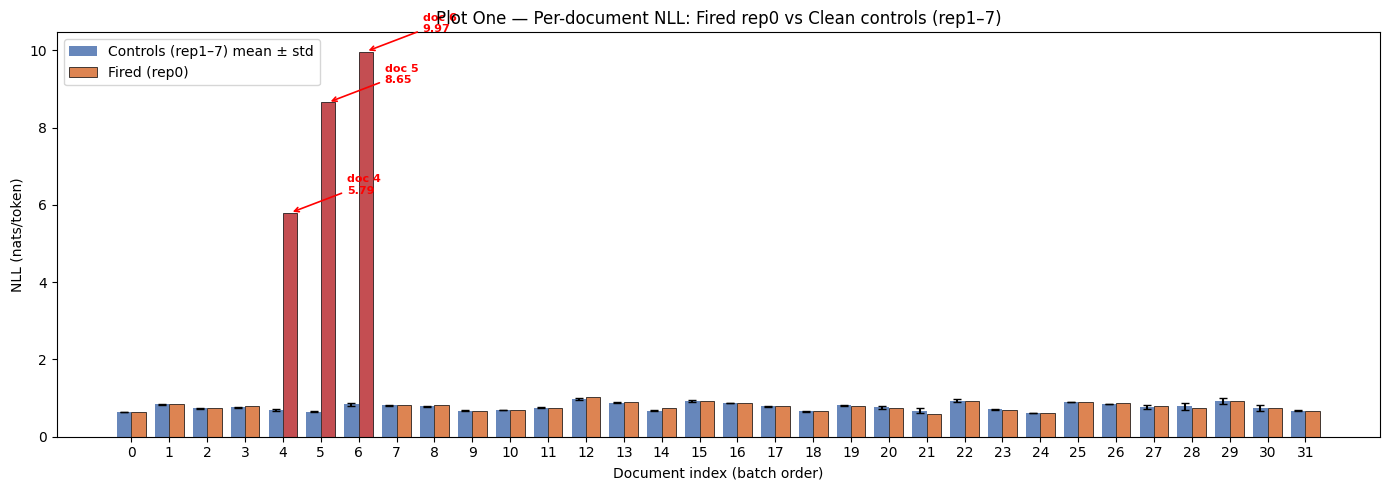

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(N_DOCS)
width = 0.38

# Control bars (mean) with std error bars
bars_ctrl = ax.bar(x - width/2, ctrl_mean, width, yerr=ctrl_std,
                   label="Controls (rep1–7) mean ± std", color="#4C72B0",
                   capsize=3, alpha=0.85)

# Fired bars
fired_colors = ["#C44E52" if i in destroyed_docs else "#DD8452" for i in range(N_DOCS)]
bars_fired = ax.bar(x + width/2, fired, width, label="Fired (rep0)",
                    color=fired_colors, edgecolor="black", linewidth=0.5)

ax.set_xlabel("Document index (batch order)")
ax.set_ylabel("NLL (nats/token)")
ax.set_title("Plot One — Per-document NLL: Fired rep0 vs Clean controls (rep1–7)")
ax.set_xticks(x)
ax.legend(loc="upper left")

# Annotate destroyed docs
for d in destroyed_docs:
    ax.annotate(f"doc {d}\n{reps[0]['destroyed'][str(d)]:.2f}",
                xy=(d + width/2, fired[d]), xytext=(d + width/2 + 1.5, fired[d] + 0.5),
                fontsize=8, color="red", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="red", lw=1.2))

fig.tight_layout()
plt.show()

### Plot 1.0.1 — Per-token NLL, Row 0 zoom (devbox attrib_conn)


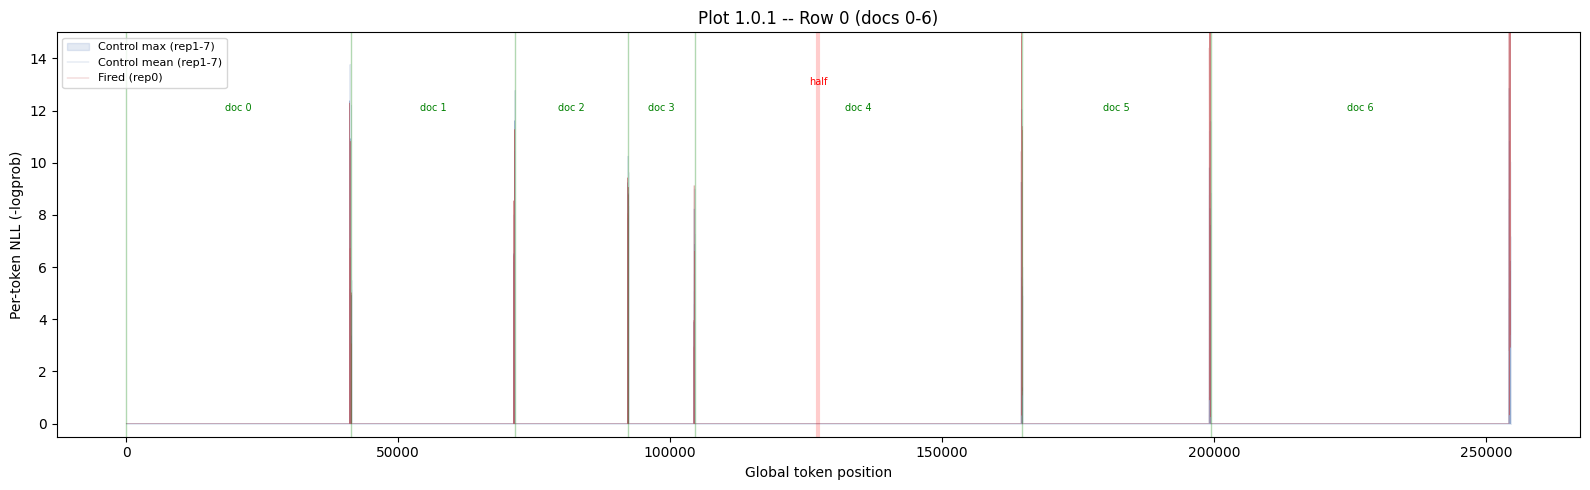

In [6]:
# Plot 1.0.1 -- Row 0 only, per-token NLL with doc boundaries
control_reps = [1, 2, 3, 4, 5, 6, 7]

# Build concatenated per-token NLL
fired_nll = np.concatenate([np.array(reps[0]['logprobs'][i], dtype=np.float64) * -1 for i in range(N_DOCS)])
tok_ctrl_list = []
for r in control_reps:
    arr = np.concatenate([np.array(reps[r]['logprobs'][i], dtype=np.float64) * -1 for i in range(N_DOCS)])
    tok_ctrl_list.append(arr)
tok_ctrl_nlls = np.stack(tok_ctrl_list)
tok_ctrl_max = tok_ctrl_nlls.max(axis=0)
tok_ctrl_mean = tok_ctrl_nlls.mean(axis=0)

# Doc boundaries
doc_lengths = [len(reps[0]['logprobs'][i]) for i in range(N_DOCS)]
doc_starts = [0]
for dl in doc_lengths:
    doc_starts.append(doc_starts[-1] + dl)

# Partition boundaries
part_boundaries = []
for ri, row_docs in enumerate(partitions):
    start = doc_starts[row_docs[0]]
    end = doc_starts[row_docs[-1]] + doc_lengths[row_docs[-1]]
    part_boundaries.append((start, end, ri))

# Half boundaries
half_boundaries = []
for ri, row_docs in enumerate(partitions):
    row_padded_total = sum(
        thd_cp_padded_length(len(payload['data'][d]['loss_fn_inputs']['weights']['data']), PAD_MULT)
        for d in row_docs
    )
    half_padded = row_padded_total / 2
    cum_padded = 0
    half_global = None
    for d in row_docs:
        n = len(payload['data'][d]['loss_fn_inputs']['weights']['data'])
        plen = thd_cp_padded_length(n, PAD_MULT)
        if cum_padded < half_padded <= cum_padded + plen:
            frac = (half_padded - cum_padded) / plen
            half_global = doc_starts[d] + int(frac * n)
            break
        cum_padded += plen
    if half_global is not None:
        half_boundaries.append(half_global)

# Plot Row 0
row_idx = 0
row_start, row_end, _ = part_boundaries[row_idx]

fig, ax = plt.subplots(figsize=(16, 5))
x_zoom = np.arange(row_start, row_end)
fired_zoom = fired_nll[row_start:row_end]
ctrl_max_zoom = tok_ctrl_max[row_start:row_end]
ctrl_mean_zoom = tok_ctrl_mean[row_start:row_end]

ax.fill_between(x_zoom, 0, ctrl_max_zoom, alpha=0.15, color="#4C72B0", label="Control max (rep1-7)")
ax.plot(x_zoom, ctrl_mean_zoom, color="#4C72B0", linewidth=0.3, alpha=0.5, label="Control mean (rep1-7)")
ax.plot(x_zoom, fired_zoom, color="#C44E52", linewidth=0.3, alpha=0.7, label="Fired (rep0)")

# Doc boundaries within row 0
for d in partitions[row_idx]:
    d_start = doc_starts[d]
    d_end = doc_starts[d + 1]
    ax.axvline(d_start, color="green", alpha=0.3, linewidth=1)
    ax.text((d_start + d_end) / 2, 12, f"doc {d}", ha="center", fontsize=7, color="green")

# Half boundary
ax.axvline(half_boundaries[row_idx], color="red", alpha=0.2, linewidth=3)
ax.text(half_boundaries[row_idx], 13, "half", ha="center", fontsize=7, color="red")

ax.set_xlabel("Global token position")
ax.set_ylabel("Per-token NLL (-logprob)")
ax.set_title(f"Plot 1.0.1 -- Row 0 (docs {partitions[row_idx][0]}-{partitions[row_idx][-1]})")
ax.legend(loc="upper left", fontsize=8)
ax.set_ylim(-0.5, 15)
fig.tight_layout()
plt.show()

### Plot 1.0.2 — Supervised tokens of a single doc (change DOC_IDX below)


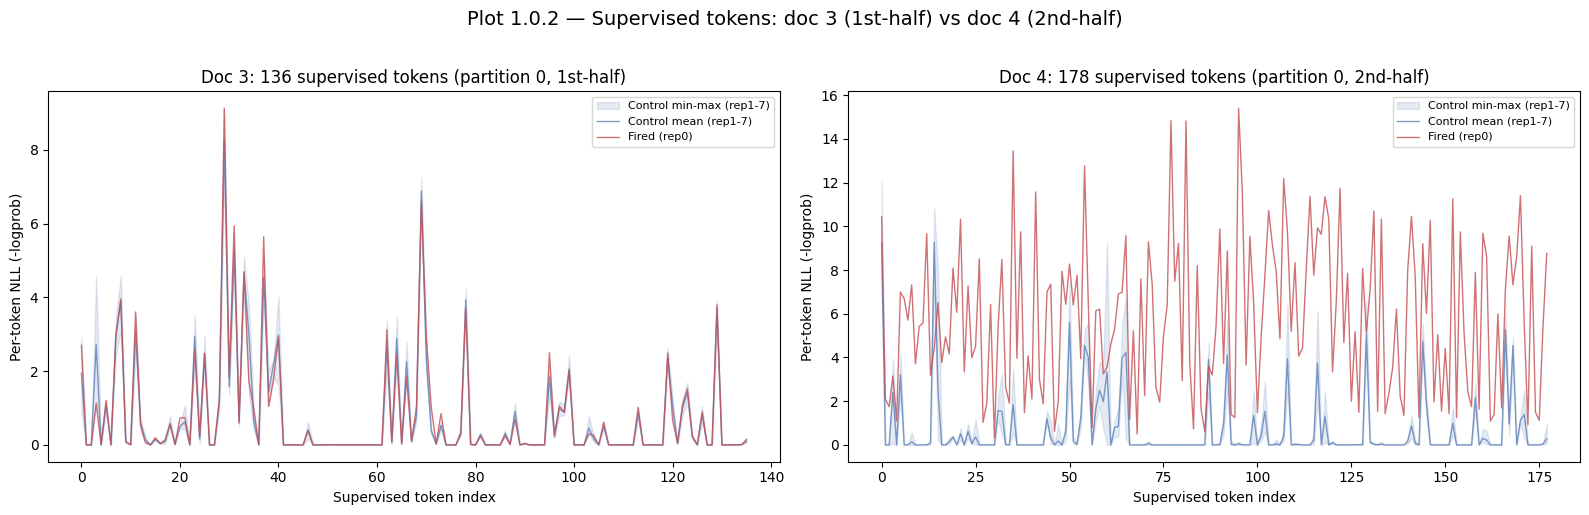

In [7]:
# Plot 1.0.2 — Supervised tokens of a single doc
control_reps = [1, 2, 3, 4, 5, 6, 7]

def plot_supervised(doc_idx, ax=None):
    s = supervised[doc_idx]
    n_sup = s["n"]

    lp_fired = np.array(reps[0]["logprobs"][doc_idx])[s["start"]:s["end"]+1]
    sctrl_data = []
    for r in control_reps:
        lp = np.array(reps[r]["logprobs"][doc_idx])[s["start"]:s["end"]+1]
        sctrl_data.append(lp)
    sctrl_arr = np.stack(sctrl_data)
    sctrl_mean = sctrl_arr.mean(axis=0)
    sctrl_max = sctrl_arr.max(axis=0)
    sctrl_min = sctrl_arr.min(axis=0)

    nll_fired = -lp_fired
    nll_sctrl_mean = -sctrl_mean
    nll_sctrl_max = -sctrl_max
    nll_sctrl_min = -sctrl_min

    x = np.arange(n_sup)
    ax.fill_between(x, nll_sctrl_min, nll_sctrl_max, alpha=0.15, color="#4C72B0", label="Control min-max (rep1-7)")
    ax.plot(x, nll_sctrl_mean, color="#4C72B0", linewidth=1, alpha=0.7, label="Control mean (rep1-7)")
    ax.plot(x, nll_fired, color="#C44E52", linewidth=1, alpha=0.8, label="Fired (rep0)")
    ax.set_xlabel("Supervised token index")
    ax.set_ylabel("Per-token NLL (-logprob)")
    ax.set_title(f"Doc {doc_idx}: {n_sup} supervised tokens (partition {doc_info[doc_idx]['partition']}, {'2nd-half' if doc_info[doc_idx]['in_second_half'] else '1st-half'})")
    ax.legend(loc="upper right", fontsize=8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_supervised(3, ax1)
plot_supervised(4, ax2)
fig.suptitle("Plot 1.0.2 — Supervised tokens: doc 3 (1st-half) vs doc 4 (2nd-half)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### Plot 1.1 — Prod per-document NLL (all partitions firing)


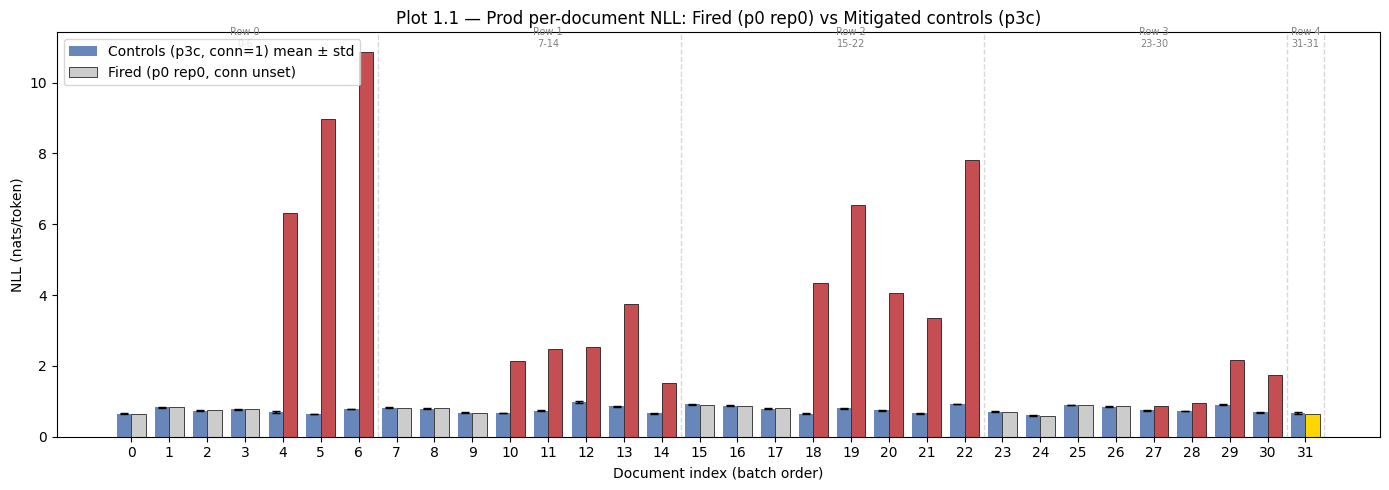

In [8]:
# Prod p0_window rep0 (conn unset, all 4 partitions fire) vs p3c (mitigated, conn=1) controls
PROD_DIR = Path("../../prod_5wolkzw")
if not PROD_DIR.exists():
    for p in Path(".").resolve().parents:
        cand = p / "parity/runs/prod_5wolkzw"
        if cand.exists():
            PROD_DIR = cand
            break

prod_fired = json.load(gzip.open(str(PROD_DIR / "p0_window_rep0.json.gz")))
prod_ctrl_reps = [json.load(gzip.open(str(PROD_DIR / f"p3c_window_rep{r}.json.gz"))) for r in range(8)]
prod_ctrl = np.array([r["nlls"] for r in prod_ctrl_reps])  # (8, 32)
prod_ctrl_mean = prod_ctrl.mean(axis=0)
prod_ctrl_std = prod_ctrl.std(axis=0)

fired_nlls = np.array(prod_fired["nlls"])

# Use partitions from the packing function above

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(N_DOCS)
width = 0.38

# Control bars (mitigated, conn=1)
ax.bar(x - width/2, prod_ctrl_mean, width, yerr=prod_ctrl_std,
       label="Controls (p3c, conn=1) mean ± std", color="#4C72B0", capsize=3, alpha=0.85)

# Fired bars — color by partition
# Color using the packing function: red = 2nd-half (vulnerable), gray = 1st-half
# Short rows (< 50% capacity) are exempt — shown with hatching
fired_colors = []
for i in range(N_DOCS):
    info = doc_info[i]
    if info["in_second_half"] and not info["short_row"]:
        fired_colors.append("#C44E52")
    elif info["in_second_half"] and info["short_row"]:
        fired_colors.append("#FFD700")  # gold = 2nd-half but short-row exempt
    else:
        fired_colors.append("#CCCCCC")

ax.bar(x + width/2, fired_nlls, width, label="Fired (p0 rep0, conn unset)",
       color=fired_colors, edgecolor="black", linewidth=0.5)

# Partition boundary lines
cum = 0
for ri, row_docs in enumerate(partitions):
    total = sum(len(payload["data"][d]["loss_fn_inputs"]["weights"]["data"]) for d in row_docs)
    # Draw partition boundary at the last doc of this row
    ax.axvline(row_docs[-1] + 0.5, color="gray", alpha=0.3, linestyle="--", linewidth=1)
    ax.text(row_docs[len(row_docs)//2], 11, f"Row {ri}\n{row_docs[0]}-{row_docs[-1]}",
            ha="center", fontsize=7, color="gray")
    cum += total

ax.set_xlabel("Document index (batch order)")
ax.set_ylabel("NLL (nats/token)")
ax.set_title("Plot 1.1 — Prod per-document NLL: Fired (p0 rep0) vs Mitigated controls (p3c)")
ax.set_xticks(x)
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

### Plot Two — Per-document NLL: Fired rep0 vs Control band (rep1-7)


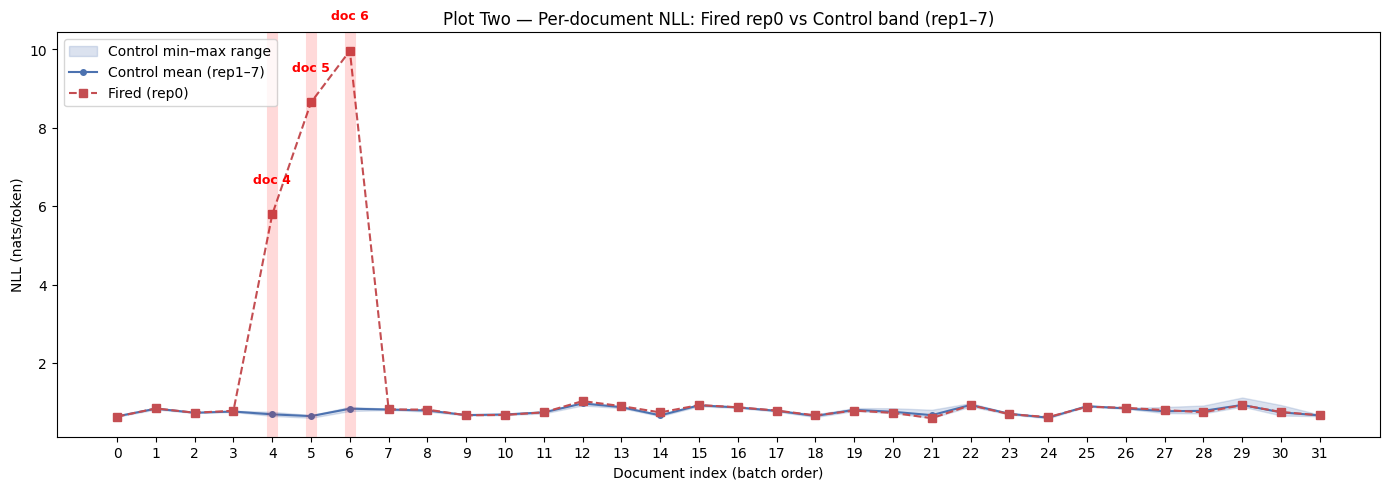

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(N_DOCS)

# Control band: min–max shaded, mean line
ax.fill_between(x, ctrl_min, ctrl_max, alpha=0.2, color="#4C72B0", label="Control min–max range")
ax.plot(x, ctrl_mean, "o-", color="#4C72B0", markersize=4, label="Control mean (rep1–7)")

# Fired line
ax.plot(x, fired, "s--", color="#C44E52", markersize=6, label="Fired (rep0)")

# Highlight destroyed docs
for d in destroyed_docs:
    ax.axvline(d, color="red", alpha=0.15, linewidth=8)
    ax.annotate(f"doc {d}", xy=(d, fired[d]), xytext=(d, fired[d] + 0.8),
                fontsize=9, color="red", fontweight="bold", ha="center")

ax.set_xlabel("Document index (batch order)")
ax.set_ylabel("NLL (nats/token)")
ax.set_title("Plot Two — Per-document NLL: Fired rep0 vs Control band (rep1–7)")
ax.set_xticks(x)
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

### Plot Three — Per-token logprobs for destroyed docs (fired vs control)


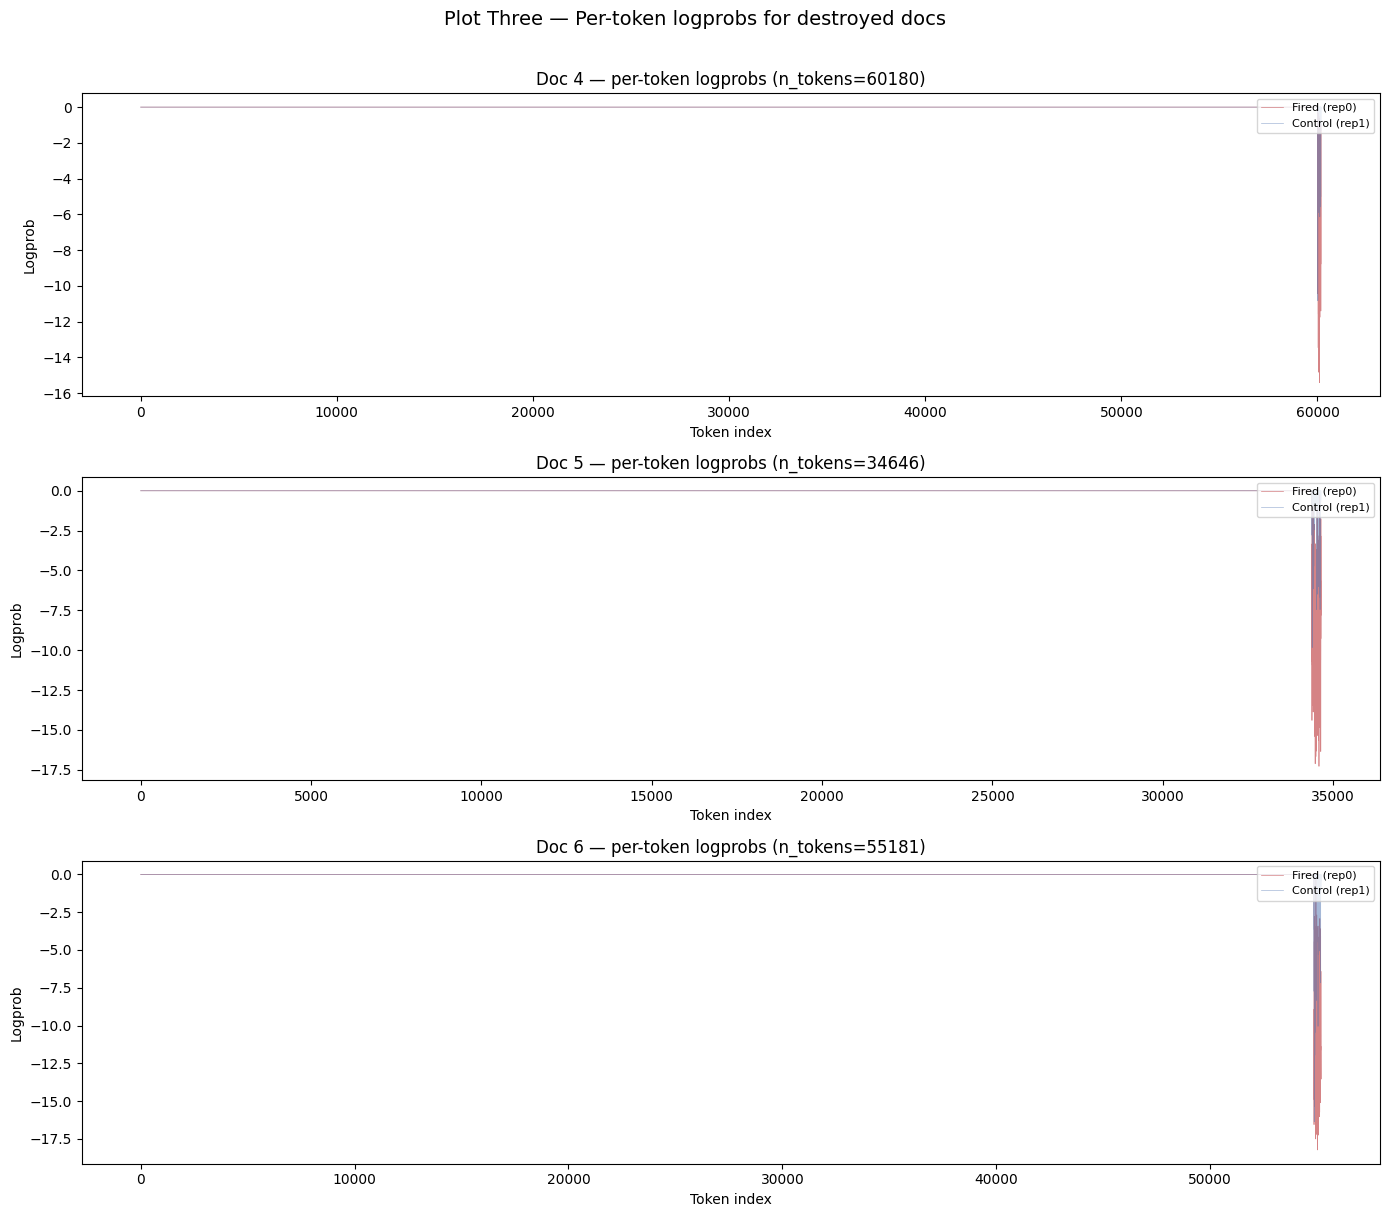

In [10]:
control_rep = 1  # use rep1 as a representative clean control

fig, axes = plt.subplots(len(destroyed_docs), 1, figsize=(14, 4 * len(destroyed_docs)), squeeze=False)

for ax, doc_idx in zip(axes[:, 0], destroyed_docs):
    lp_fired = np.array(reps[0]["logprobs"][doc_idx])
    lp_ctrl = np.array(reps[control_rep]["logprobs"][doc_idx])
    n = min(len(lp_fired), len(lp_ctrl))
    token_idx = np.arange(n)

    ax.plot(token_idx, lp_fired[:n], color="#C44E52", alpha=0.7, linewidth=0.5, label="Fired (rep0)")
    ax.plot(token_idx, lp_ctrl[:n], color="#4C72B0", alpha=0.5, linewidth=0.5, label=f"Control (rep{control_rep})")

    ax.set_title(f"Doc {doc_idx} — per-token logprobs (n_tokens={n})")
    ax.set_xlabel("Token index")
    ax.set_ylabel("Logprob")
    ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Plot Three — Per-token logprobs for destroyed docs", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

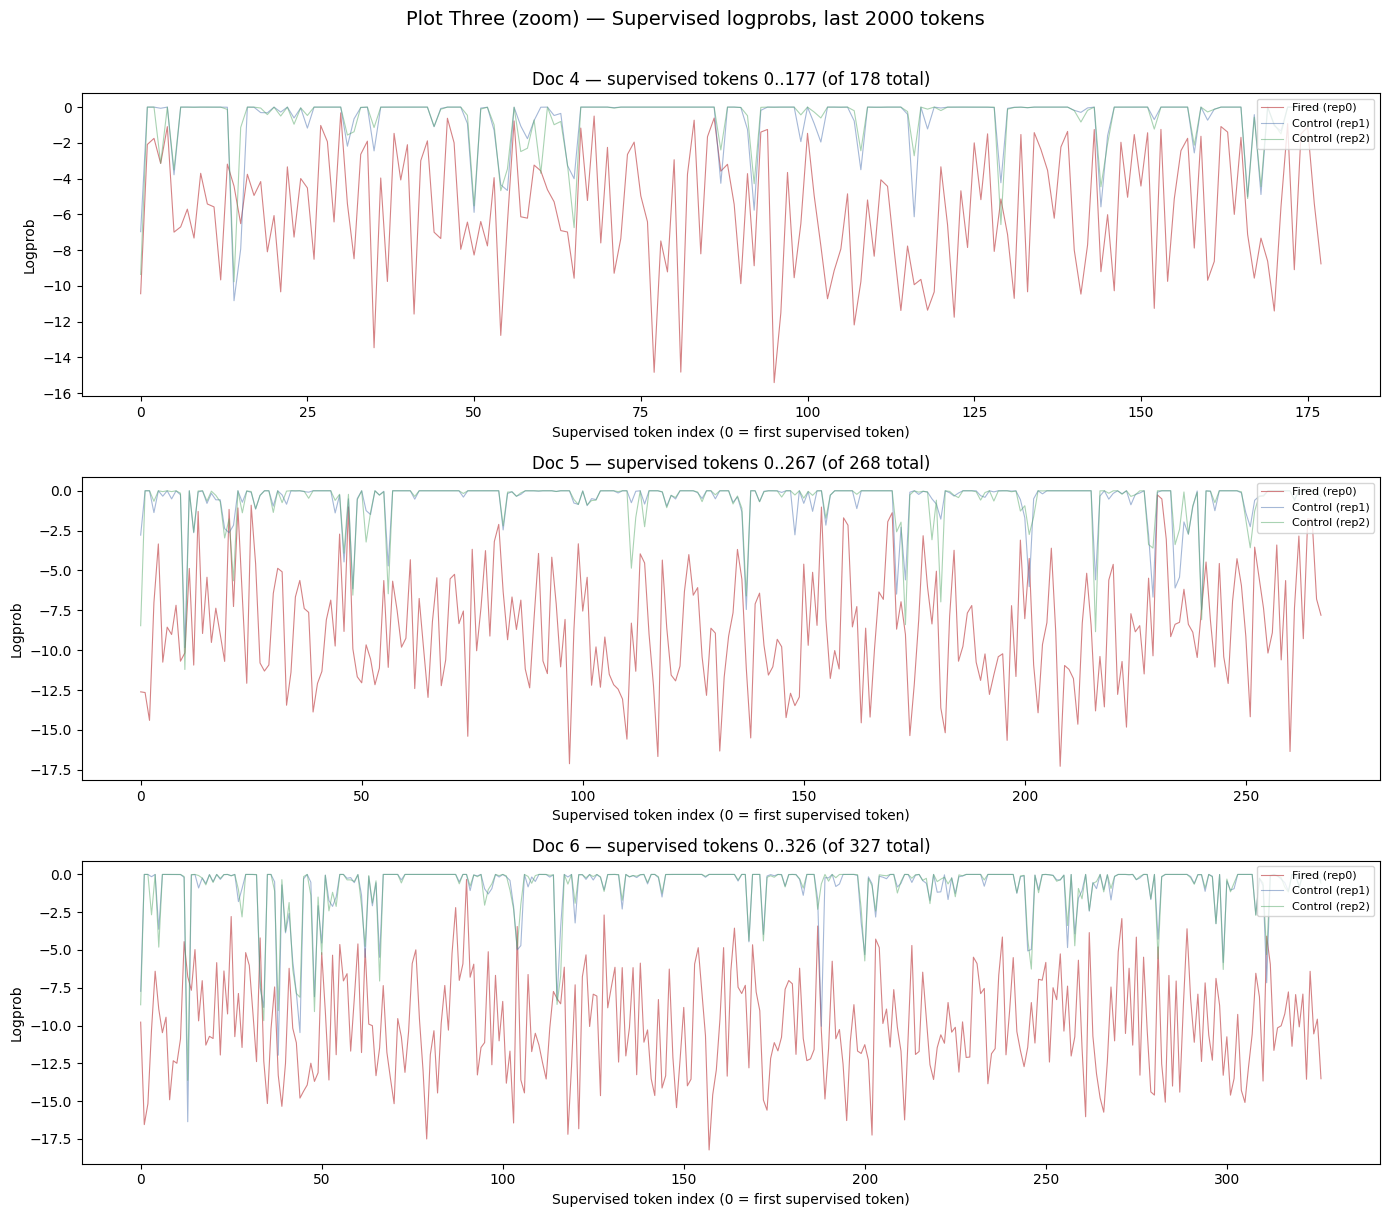

In [11]:
# Plot Three (zoom): only supervised tokens, index 0 = first supervised token
control_rep1 = 1
control_rep2 = 2
ZOOM = 2000  # number of supervised tokens to show (from the end)

fig, axes = plt.subplots(len(destroyed_docs), 1, figsize=(14, 4 * len(destroyed_docs)), squeeze=False)

for ax, doc_idx in zip(axes[:, 0], destroyed_docs):
    s = supervised[doc_idx]
    n_sup = s["n"]
    start = max(0, n_sup - ZOOM)
    token_idx = np.arange(start, n_sup)

    # Extract supervised logprobs: only the positions with weight > 0
    lp_fired = np.array(reps[0]["logprobs"][doc_idx])[s["start"]:s["end"]+1]
    lp_ctrl1 = np.array(reps[control_rep1]["logprobs"][doc_idx])[s["start"]:s["end"]+1]
    lp_ctrl2 = np.array(reps[control_rep2]["logprobs"][doc_idx])[s["start"]:s["end"]+1]

    ax.plot(token_idx, lp_fired[start:n_sup], color="#C44E52", alpha=0.7, linewidth=0.8, label="Fired (rep0)")
    ax.plot(token_idx, lp_ctrl1[start:n_sup], color="#4C72B0", alpha=0.5, linewidth=0.8, label=f"Control (rep{control_rep1})")
    ax.plot(token_idx, lp_ctrl2[start:n_sup], color="#55A868", alpha=0.5, linewidth=0.8, label=f"Control (rep{control_rep2})")

    ax.set_title(f"Doc {doc_idx} — supervised tokens {start}..{n_sup-1} (of {n_sup} total)")
    ax.set_xlabel("Supervised token index (0 = first supervised token)")
    ax.set_ylabel("Logprob")
    ax.legend(loc="upper right", fontsize=8)

fig.suptitle(f"Plot Three (zoom) — Supervised logprobs, last {ZOOM} tokens", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

In [12]:
# Decoded supervised text for each destroyed doc
for doc_idx in destroyed_docs:
    s = supervised[doc_idx]
    print(f"{'='*80}")
    print(f"Doc {doc_idx} — {s['n']} supervised tokens:")
    print(f"{'='*80}")
    print(s["text"])
    print()

Doc 4 — 178 supervised tokens:
{"starting_point": "NCCN Cervical Cancer guideline (Citation 19) directly addresses second-line therapy for recurrent/metastatic cervical cancer with category 1 recommendation for tisotumab vedotin and category 2A for multiple other agents; adopting authoritative shortcut as current evidence-based guideline with strong recommendations.", "upgrades_triggered": [{"check": "5c_convergence_strong_sources", "reason": "NCCN guideline, phase 3 innovaTV 301 RCT (Vergote et al.), NEJM review (Tewari), SGO practice statement (Girda et al.), and FDA label all converge on tisotumab vedotin as preferred second-line option."}], "downgrades_triggered": [], "rationale": "Guideline plus phase 3 RCT; consistent multi-source convergence", "grade": "A"}

Doc 5 — 268 supervised tokens:
{"starting_point": "Ceiling set at B based on highest starting Quality of M from multiple SRs/MAs of observational studies (Rahman et al., Machado et al., Nochaiwong et al.) and observational s

### Plot Four — Cumulative mean NLL for destroyed docs


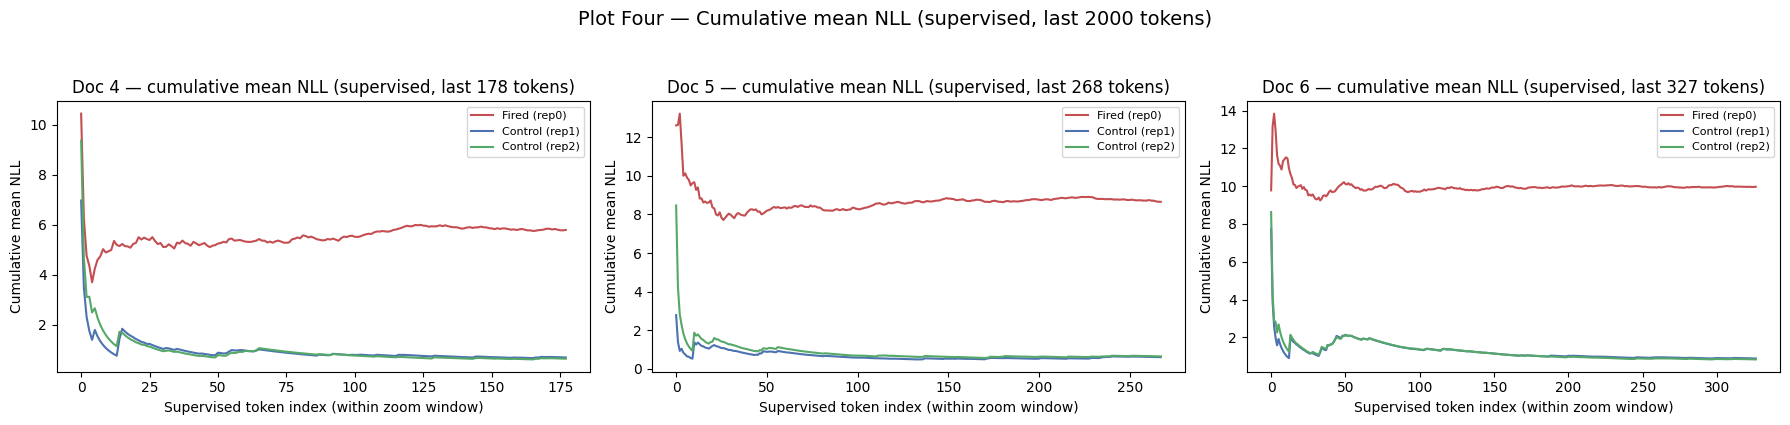

In [13]:
# Plot Four: cumulative mean NLL over supervised tokens, same ZOOM as Plot Three
control_rep1 = 1
control_rep2 = 2

fig, axes = plt.subplots(1, len(destroyed_docs), figsize=(6 * len(destroyed_docs), 4), squeeze=False)

for ax, doc_idx in zip(axes[0], destroyed_docs):
    s = supervised[doc_idx]
    n_sup = s["n"]
    start = max(0, n_sup - ZOOM)

    lp_fired = np.array(reps[0]["logprobs"][doc_idx])[s["start"]:s["end"]+1]
    lp_ctrl1 = np.array(reps[control_rep1]["logprobs"][doc_idx])[s["start"]:s["end"]+1]
    lp_ctrl2 = np.array(reps[control_rep2]["logprobs"][doc_idx])[s["start"]:s["end"]+1]

    # Cumulative mean NLL = cumsum(-lp) / arange, within the zoom window
    cum_nll_fired = np.cumsum(-lp_fired[start:n_sup]) / (np.arange(n_sup - start) + 1)
    cum_nll_ctrl1 = np.cumsum(-lp_ctrl1[start:n_sup]) / (np.arange(n_sup - start) + 1)
    cum_nll_ctrl2 = np.cumsum(-lp_ctrl2[start:n_sup]) / (np.arange(n_sup - start) + 1)

    ax.plot(cum_nll_fired, color="#C44E52", label="Fired (rep0)")
    ax.plot(cum_nll_ctrl1, color="#4C72B0", label=f"Control (rep{control_rep1})")
    ax.plot(cum_nll_ctrl2, color="#55A868", label=f"Control (rep{control_rep2})")
    ax.set_title(f"Doc {doc_idx} — cumulative mean NLL (supervised, last {n_sup - start} tokens)")
    ax.set_xlabel("Supervised token index (within zoom window)")
    ax.set_ylabel("Cumulative mean NLL")
    ax.legend(fontsize=8)

fig.suptitle(f"Plot Four — Cumulative mean NLL (supervised, last {ZOOM} tokens)", fontsize=14, y=1.05)
fig.tight_layout()
plt.show()